## Assignment 1
**Name:** Jibril Hussaini
**Code:** <student ID>

Linear regression on the California Housing dataset.

### 1. Import required libraries

In [1]:
# dplyr for data wrangling, ggplot2 for plotting, caret for the ML workflow
library(dplyr)
library(ggplot2)
library(caret)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: lattice



### 2. Load the California Housing Dataset

In [2]:
# Same data as the Python notebook, exported to CSV from scikit-learn
df <- read.csv("california_housing.csv")

### 3. Display the first 5 rows of the dataset

In [3]:
head(df, 5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8.3252,41,6.984127,1.0238095,322,2.555556,37.88,-122.23,4.526
2,8.3014,21,6.238137,0.9718805,2401,2.109842,37.86,-122.22,3.585
3,7.2574,52,8.288136,1.0734463,496,2.802260,37.85,-122.24,3.521
4,5.6431,52,5.817352,1.0730594,558,2.547945,37.85,-122.25,3.413
5,3.8462,52,6.281853,1.0810811,565,2.181467,37.85,-122.25,3.422


### 4. Check for missing data (if any)

In [4]:
# Number of missing values per column
colSums(is.na(df))

MedInc    HouseAge    AveRooms   AveBedrms  Population    AveOccup 
          0           0           0           0           0           0 
   Latitude   Longitude MedHouseVal 
          0           0           0

### 5. Handle missing data (impute with mean values)

In [5]:
# Replace any NA with the column mean (none here, kept for completeness)
df <- df %>% mutate(across(everything(), ~ ifelse(is.na(.), mean(., na.rm = TRUE), .)))
cat("Total missing values after imputation:", sum(is.na(df)), "\n")

Total missing values after imputation: 0 


### 6. Feature scaling using StandardScaler

In [6]:
# Standardise the feature columns (z-score); leave the target untouched
features <- setdiff(names(df), "MedHouseVal")
df[features] <- scale(df[features])

### 7. Split the dataset into train and test sets

In [7]:
# 80% training, 20% testing, using caret's partition
set.seed(42)
idx <- createDataPartition(df$MedHouseVal, p = 0.8, list = FALSE)
train <- df[idx, ]
test  <- df[-idx, ]
cat("Train:", nrow(train), "| Test:", nrow(test), "\n")

Train: 16513 | Test: 4127 


### 8. Train a linear regression model

In [8]:
model <- lm(MedHouseVal ~ ., data = train)

### 9. Predict on the test set

In [9]:
predictions <- predict(model, newdata = test)

### 10. Evaluate the model (R² and MSE)

In [10]:
# postResample gives RMSE / Rsquared / MAE; MSE is RMSE squared
metrics <- postResample(pred = predictions, obs = test$MedHouseVal)
cat("R2 score:", round(metrics["Rsquared"], 4), "\n")
cat("MSE     :", round(metrics["RMSE"]^2, 4), "\n")

R2 score: 0.5916 


MSE     : 0.5644 


### 11. Display learned weights for each feature and the bias

In [11]:
# (Intercept) is the bias; the remaining coefficients are the per-feature weights
coef(model)

(Intercept)       MedInc     HouseAge     AveRooms    AveBedrms   Population 
 2.067091587  0.850237154  0.122110754 -0.301370381  0.374198080 -0.001207538 
    AveOccup     Latitude    Longitude 
-0.036279234 -0.898310386 -0.867275791

### 12. Visualize predicted vs actual house prices

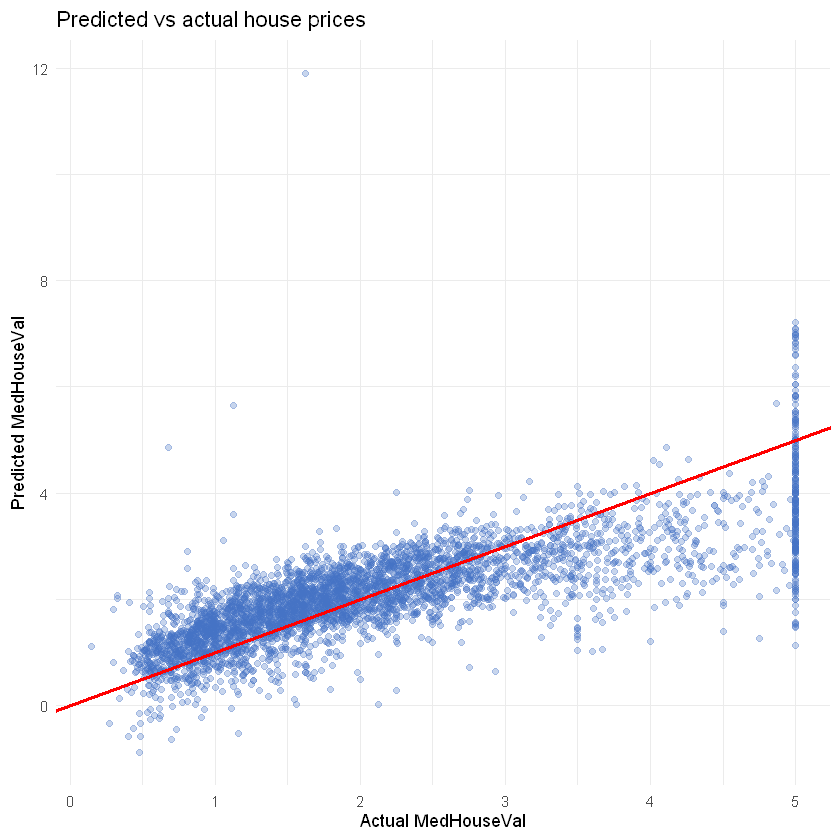

In [12]:
ggplot(data.frame(actual = test$MedHouseVal, predicted = predictions),
       aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.3, color = "#4472C4") +
  geom_abline(slope = 1, intercept = 0, color = "red", linewidth = 1) +
  labs(title = "Predicted vs actual house prices",
       x = "Actual MedHouseVal", y = "Predicted MedHouseVal") +
  theme_minimal()